# Simio – Single-run report (one system)
This notebook loads the CSV outputs produced by `simio_xtc_all_properties` for **one trajectory/system** and prints + plots a compact, non-duplicated set of diagnostics.

**Expected files (prefix `analysis_` by default):** density_x, dipole_x, coord_x, gating_flux, jump_msd, msd_x_channel, msd_z_channel, vacf_y, vacf_z_channel_raw, vacf_x_channel.


In [3]:

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120


## 0) Locate outputs
Set `RUN_DIR` to the simio output directory (for example `runs/rep_01`).\nThe notebook will write figures and tables into `RUN_DIR/report/`.


In [4]:
RUN_DIR = Path(os.environ.get("SIMIO_RUN_DIR", "runs/rep_01"))
REPORT_DIR = RUN_DIR / "report"
FIG_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"RUN_DIR    : {RUN_DIR}")
print(f"REPORT_DIR : {REPORT_DIR}")
print(f"FIG_DIR    : {FIG_DIR}")

def resolve_csv(run_dir: Path, name: str) -> Path:
    candidates = [
        run_dir / f"{name}.csv",
        run_dir / f"results_{name}.csv",
    ]
    for p in candidates:
        if p.exists():
            return p
    return candidates[0]

def savefig_and_show(name: str, fig=None):
    if fig is None:
        fig = plt.gcf()
    out = FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {out}")

files = {
    "density_x": resolve_csv(RUN_DIR, "density_x"),
    "density_z": resolve_csv(RUN_DIR, "density_z"),
    "dipole_x": resolve_csv(RUN_DIR, "dipole_x"),
    "coord_x": resolve_csv(RUN_DIR, "coord_x"),
    "gating_flux": resolve_csv(RUN_DIR, "gating_flux"),
    "jump_msd": resolve_csv(RUN_DIR, "jump_msd"),
    "msd_x_channel": resolve_csv(RUN_DIR, "msd_x_channel"),
    "msd_z_channel": resolve_csv(RUN_DIR, "msd_z_channel"),
    "vacf_y": resolve_csv(RUN_DIR, "vacf_y"),
    "vacf_z_channel_raw": resolve_csv(RUN_DIR, "vacf_z_channel_raw"),
    "vacf_x_channel": resolve_csv(RUN_DIR, "vacf_x_channel"),
}

present = {k: p for k,p in files.items() if p.exists()}
missing = {k: str(p) for k,p in files.items() if not p.exists()}

print("Present files:")
for k,p in present.items():
    print(f"  - {k:18s}: {p}")
if missing:
    print("\nMissing files (skipped gracefully):")
    for k,p in missing.items():
        print(f"  - {k:18s}: {p}")


Present files:

Missing files:
  - density_x         : results_density_x.csv
  - dipole_x          : results_dipole_x.csv
  - coord_x           : results_coord_x.csv
  - gating_flux       : results_gating_flux.csv
  - jump_msd          : results_jump_msd.csv
  - msd_x_channel     : results_msd_x_channel.csv
  - msd_z_channel     : results_msd_z_channel.csv
  - vacf_y            : results_vacf_y.csv
  - vacf_z_channel_raw: results_vacf_z_channel_raw.csv
  - vacf_x_channel    : results_vacf_x_channel.csv


## Helpers

In [5]:
def read_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Fix occasional stray characters in first header (e.g. ']lag_frames')
    if df.columns[0].startswith("]"):
        df = df.rename(columns={df.columns[0]: df.columns[0].lstrip("]")})
    return df

def tail_stats(series: pd.Series, n=10):
    tail = series.tail(n)
    return float(tail.mean()), float(tail.std()), float(tail.iloc[-1]), float(tail.iloc[0])

def linfit(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if len(x) < 2:
        return np.nan, np.nan, np.nan
    A = np.vstack([x, np.ones_like(x)]).T
    slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
    # R^2
    yhat = slope*x + intercept
    ss_res = np.sum((y-yhat)**2)
    ss_tot = np.sum((y-np.mean(y))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return float(slope), float(intercept), float(r2)

def show_summary_df(rows, title="Summary"):
    if not rows:
        print(f"{title}: no rows")
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    display(df)
    return df

def save_table(df: pd.DataFrame, filename: str):
    out = REPORT_DIR / filename
    df.to_csv(out, index=False)
    print(f"Saved table: {out}")
    return out


## 1) Density profiles along x

In [7]:
if files["density_x"].exists():
    df = read_csv(files["density_x"])
    # Expect columns like: x_center_nm, rho_water_mean, rho_na_mean, rho_cl_mean (or *_nm3)
    xcol = [c for c in df.columns if c.startswith("x")][0]
    candidates = [c for c in df.columns if "rho" in c]
    print("Columns:", xcol, candidates)

    fig, ax = plt.subplots(figsize=(7.5,4.2))
    for c in candidates:
        ax.plot(df[xcol], df[c], label=c)
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("number density (1/nm³)")
    ax.set_title("Density profiles")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    savefig_and_show("density_x", fig)


## 2) Dipole profiles along x

Columns: x_center_nm ['muz_mean', 'muz_sem', 'muz_fold_mean', 'muz_fold_sem', 'mux_mean', 'mux_sem']


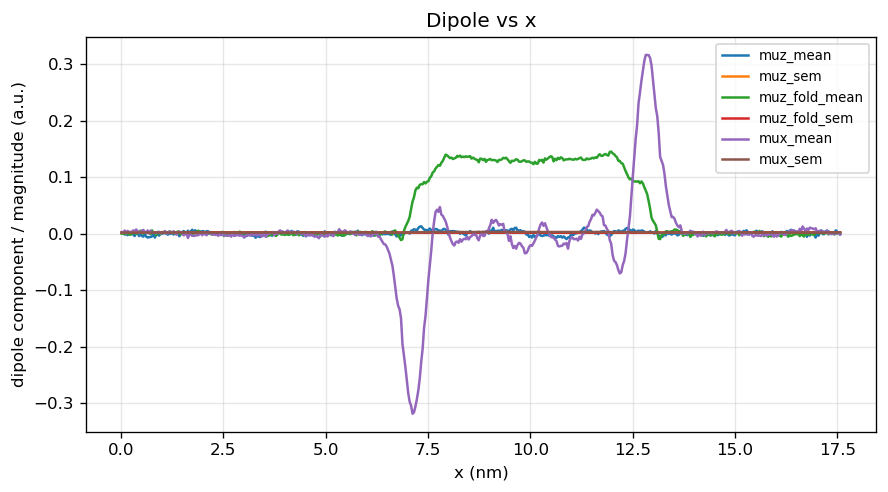

In [17]:
if files["dipole_x"].exists():
    df = read_csv(files["dipole_x"])
    xcol = [c for c in df.columns if c.startswith("x")][0]
    dcols = [c for c in df.columns if ("dip" in c.lower() or "mu" in c.lower()) and c != xcol]
    print("Columns:", xcol, dcols)

    fig, ax = plt.subplots(figsize=(7.5,4.2))
    for c in dcols:
        ax.plot(df[xcol], df[c], label=c)
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("dipole component / magnitude (a.u.)")
    ax.set_title("Dipole vs x")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    savefig_and_show("dipole_x", fig)


## 3) Coordination / H-bond style observables along x

Columns: x_center_nm ['IBC_mean', 'IBC_sem', 'IBA_mean', 'IBA_sem', 'BNC_mean', 'BNC_sem', 'BNA_mean', 'BNA_sem', 'BWW_mean', 'BWW_sem', 'HBww_don_mean', 'HBww_don_sem', 'HBww_acc_mean', 'HBww_acc_sem', 'HBww_tot_mean', 'HBww_tot_sem', 'HBwcl_don_mean', 'HBwcl_don_sem']


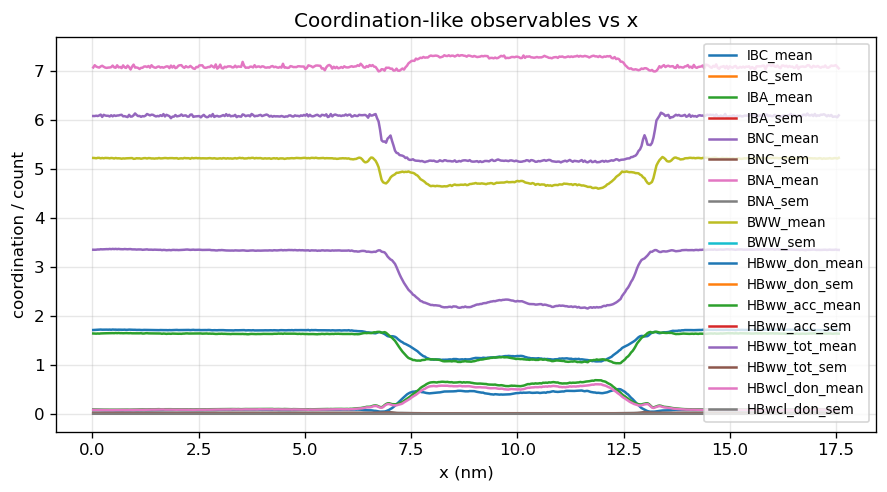

In [18]:
if files["coord_x"].exists():
    df = read_csv(files["coord_x"])
    xcol = [c for c in df.columns if c.startswith("x")][0]
    cols = [c for c in df.columns if c != xcol]
    print("Columns:", xcol, cols)

    fig, ax = plt.subplots(figsize=(7.5,4.2))
    for c in cols:
        ax.plot(df[xcol], df[c], label=c)
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("coordination / count")
    ax.set_title("Coordination-like observables vs x")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    savefig_and_show("coord_x", fig)


## 4) Gating flux (counts + simple slope fits)
This is *counts vs time*; we fit the linear regime to get net rate. Interpret per your chosen gate definition.

Columns: ['frame_idx', 'step', 'time_ps', 'center_water_left', 'center_water_right', 'center_water_cum_right', 'seam_water_left', 'seam_water_right', 'seam_water_cum_right', 'center_na_left', 'center_na_right', 'center_na_cum_right', 'seam_na_left', 'seam_na_right', 'seam_na_cum_right', 'center_cl_left', 'center_cl_right', 'center_cl_cum_right', 'seam_cl_left', 'seam_cl_right', 'seam_cl_cum_right']


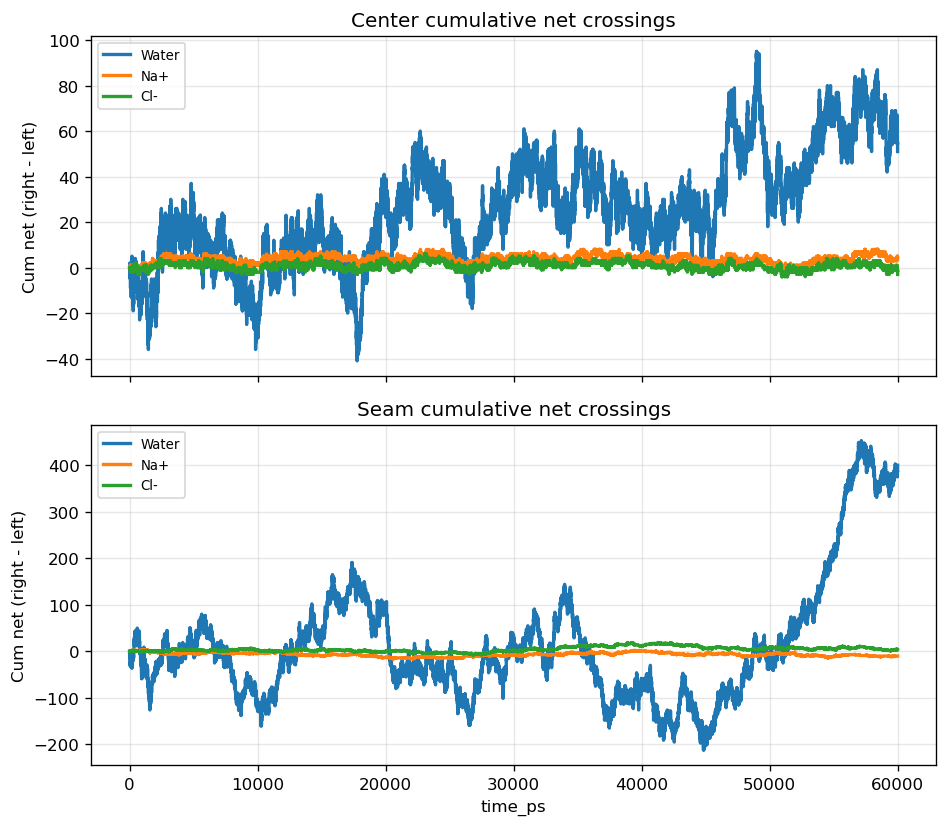

,series,fit_window,slope (net/ps),R2
0,center_water_cum_net,[10000:20000],0.001213,0.300048
1,center_na_cum_net,[10000:20000],-0.000035,0.028072
2,center_cl_cum_net,[10000:20000],-0.000081,0.181276
3,seam_water_cum_net,[10000:20000],0.012059,0.372656
4,seam_na_cum_net,[10000:20000],-0.000190,0.264696
5,seam_cl_cum_net,[10000:20000],-0.000126,0.066194


In [19]:
if files["gating_flux"].exists():
    df = read_csv(files["gating_flux"])
    print("Columns:", list(df.columns))

    tcol = "time_ps" if "time_ps" in df.columns else ("frame_idx" if "frame_idx" in df.columns else df.columns[0])

    planes = ["center", "seam"]
    species = ["water", "na", "cl"]

    # Build derived net and cumulative-net columns
    cum_net_cols = []
    for p in planes:
        for s in species:
            l = f"{p}_{s}_left"
            r = f"{p}_{s}_right"
            if l in df.columns and r in df.columns:
                net = f"{p}_{s}_net"
                cum_net = f"{p}_{s}_cum_net"
                df[net] = df[r] - df[l]
                df[cum_net] = df[net].cumsum()
                cum_net_cols.append(cum_net)

    # Plot: first center, second seam; each has water/na/cl cumulative net
    fig, axs = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    for i, p in enumerate(planes):
        ax = axs[i]
        for s, lbl in [("water", "Water"), ("na", "Na+"), ("cl", "Cl-")]:
            c = f"{p}_{s}_cum_net"
            if c in df.columns:
                ax.plot(df[tcol], df[c], label=lbl, lw=2)
        ax.set_title(f"{p.capitalize()} cumulative net crossings")
        ax.set_ylabel("Cum net (right - left)")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    axs[-1].set_xlabel(tcol)
    plt.tight_layout()
    savefig_and_show("gating_flux", fig)

    # Optional: fit slope on last half
    i0 = len(df) // 2
    rows = []
    for c in cum_net_cols:
        slope, intercept, r2 = linfit(df[tcol].iloc[i0:], df[c].iloc[i0:])
        rows.append({
            "series": c,
            "fit_window": f"[{i0}:{len(df)-1}]",
            "slope (net/ps)": slope,
            "R2": r2
        })
    if rows:
        gating_fit = show_summary_df(rows, "gating fit")
        save_table(gating_fit, "gating_flux_fit_table.csv")


## 5) MSD baselines + channel-restricted MSD
- `jump_msd`: slab-start MSD_x/y/z (baseline)
- `msd_x_channel`: channel-survival MSD_x
- `msd_z_channel`: channel-survival MSD_z (raw vs unwrapped)

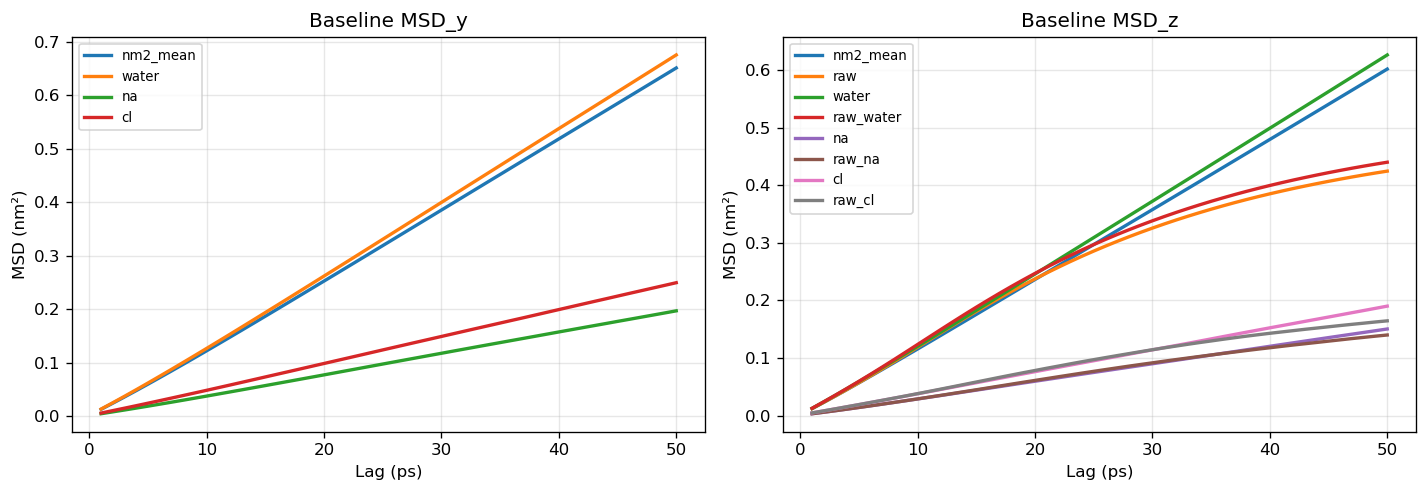

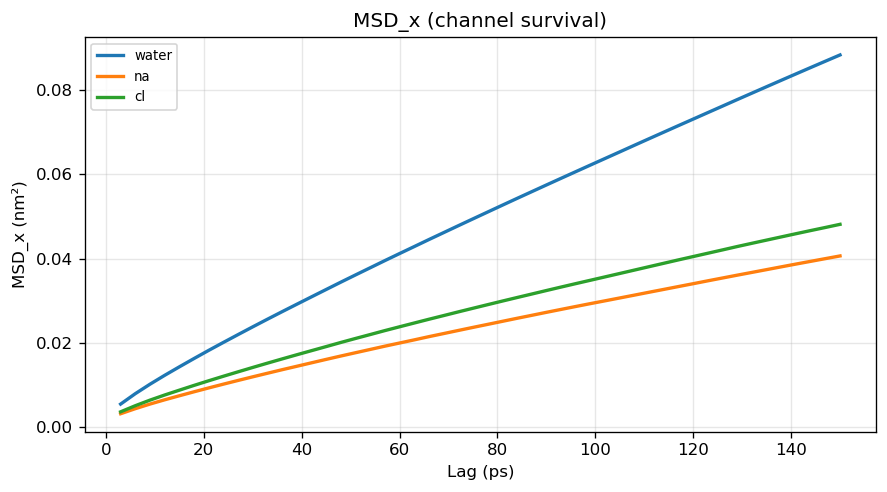

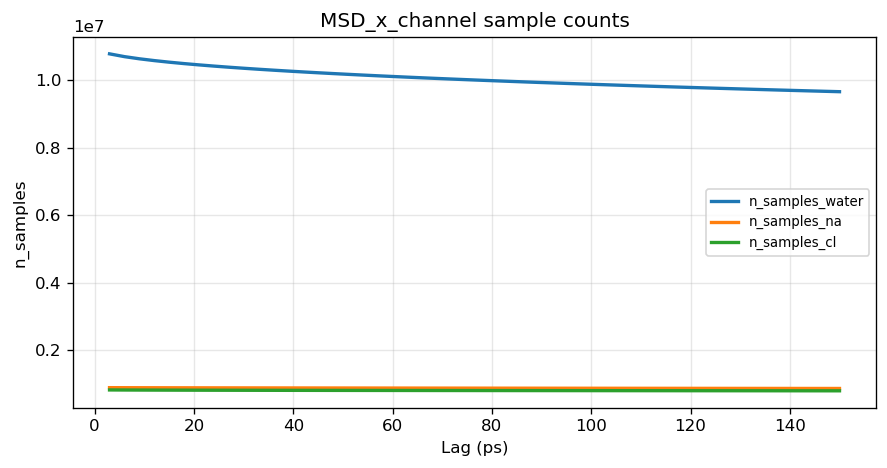

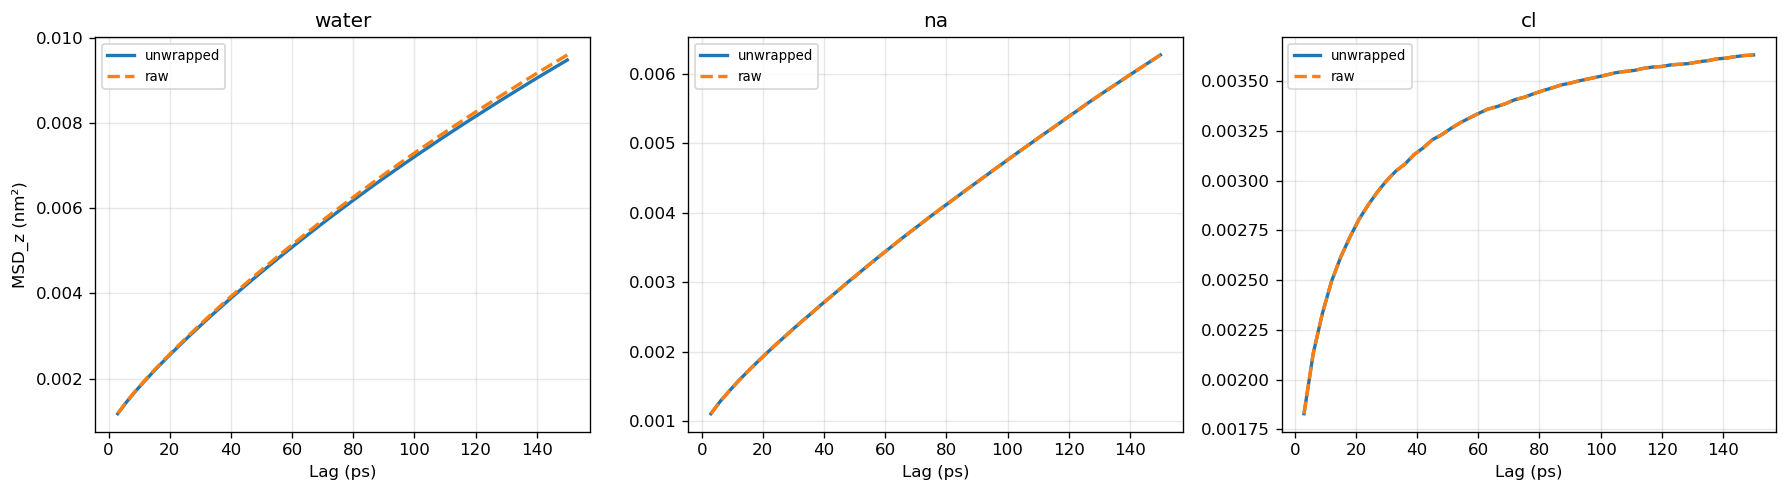

In [20]:
# Baseline MSD_y/z from jump_msd
if files["jump_msd"].exists():
    df = read_csv(files["jump_msd"])
    lag = df["lag_ps"] if "lag_ps" in df.columns else df["lag_frames"]

    # plot MSD_y and MSD_z if present
    ycols = [c for c in df.columns if c.startswith("msd_y_") and c.endswith("_mean")]
    zcols = [c for c in df.columns if c.startswith("msd_z_") and c.endswith("_mean")]

    if ycols or zcols:
        fig, axs = plt.subplots(1, 2, figsize=(12,4.2), sharex=True)
        for c in ycols:
            axs[0].plot(lag, df[c], label=c.replace("msd_y_","").replace("_nm2_mean",""), lw=2)
        axs[0].set_title("Baseline MSD_y")
        axs[0].set_xlabel("Lag (ps)")
        axs[0].set_ylabel("MSD (nm²)")
        axs[0].grid(alpha=0.3)
        axs[0].legend(fontsize=8)

        for c in zcols:
            axs[1].plot(lag, df[c], label=c.replace("msd_z_","").replace("_nm2_mean",""), lw=2)
        axs[1].set_title("Baseline MSD_z")
        axs[1].set_xlabel("Lag (ps)")
        axs[1].set_ylabel("MSD (nm²)")
        axs[1].grid(alpha=0.3)
        axs[1].legend(fontsize=8)

        plt.tight_layout()
        savefig_and_show("jump_msd", fig)

# Channel-survival MSD_x
if files["msd_x_channel"].exists():
    df = read_csv(files["msd_x_channel"])
    lag = df["lag_ps"] if "lag_ps" in df.columns else df["lag_frames"]
    cols = [c for c in df.columns if c.startswith("msd_x_channel_") and c.endswith("_mean")]
    fig, ax = plt.subplots(figsize=(7.5,4.2))
    for c in cols:
        ax.plot(lag, df[c], label=c.replace("msd_x_channel_","").replace("_nm2_mean",""), lw=2)
    ax.set_title("MSD_x (channel survival)")
    ax.set_xlabel("Lag (ps)")
    ax.set_ylabel("MSD_x (nm²)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    savefig_and_show("msd_x_channel", fig)

    # sample counts
    ncols = [c for c in df.columns if c.startswith("n_samples")]
    if ncols:
        fig, ax = plt.subplots(figsize=(7.5,4.0))
        for c in ncols:
            ax.plot(lag, df[c], label=c, lw=2)
        ax.set_title("MSD_x_channel sample counts")
        ax.set_xlabel("Lag (ps)")
        ax.set_ylabel("n_samples")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
        plt.tight_layout()
        savefig_and_show("msd_x_channel_samples", fig)

# Channel-survival MSD_z (raw vs unwrapped)
if files["msd_z_channel"].exists():
    df = read_csv(files["msd_z_channel"])
    lag = df["lag_ps"] if "lag_ps" in df.columns else df["lag_frames"]
    fig, axs = plt.subplots(1, 3, figsize=(15,4.2), sharex=True)
    for i,sp in enumerate(["water","na","cl"]):
        cu = f"msd_z_channel_unwrapped_{sp}_nm2_mean"
        cr = f"msd_z_channel_raw_{sp}_nm2_mean"
        if cu in df.columns:
            axs[i].plot(lag, df[cu], label="unwrapped", lw=2)
        if cr in df.columns:
            axs[i].plot(lag, df[cr], label="raw", lw=2, ls="--")
        axs[i].set_title(sp)
        axs[i].set_xlabel("Lag (ps)")
        axs[i].grid(alpha=0.3)
        axs[i].legend(fontsize=8)
    axs[0].set_ylabel("MSD_z (nm²)")
    plt.tight_layout()
    savefig_and_show("msd_z_channel", fig)


## 6) VACF_y (diffusive check) and D_y plateau

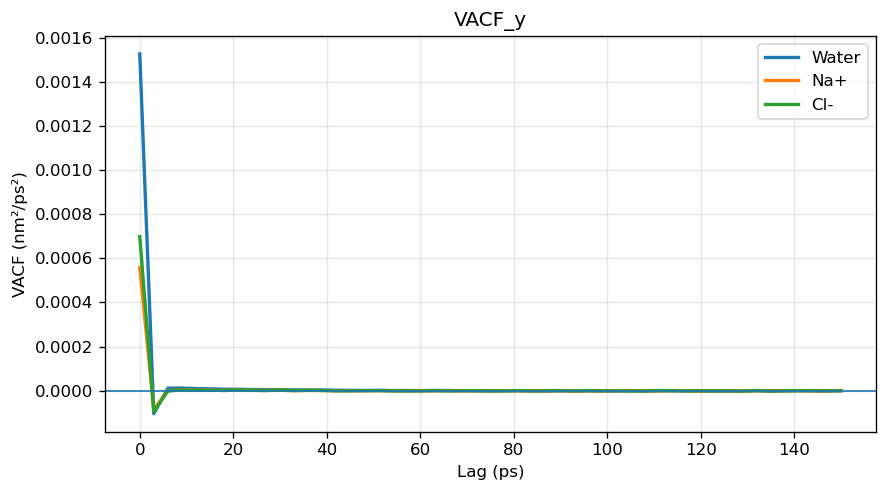

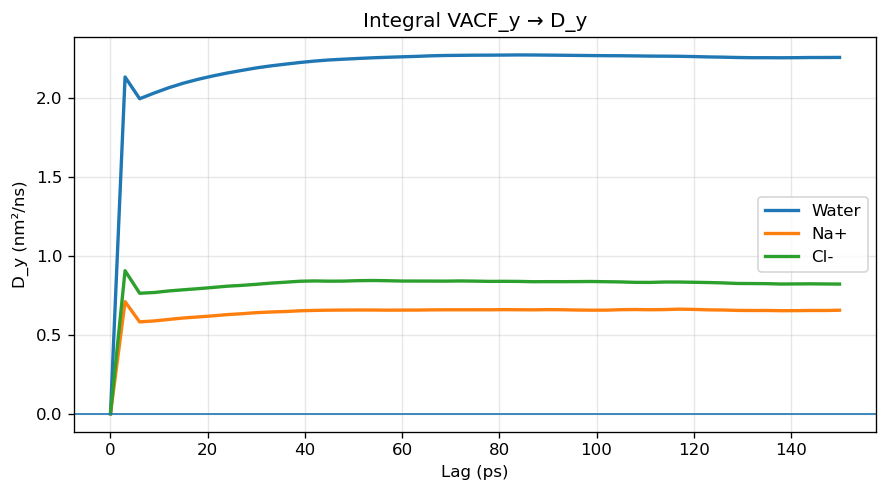

,species,D_y plateau mean (nm²/ns),std(last10),D_y(last)
0,water,2.256595,0.001676,2.256970
1,na,0.654638,0.001741,0.655671
2,cl,0.824326,0.003242,0.821240


In [21]:
if files["vacf_y"].exists():
    df = read_csv(files["vacf_y"])
    lag = df["lag_ps"] if "lag_ps" in df.columns else df["lag_frames"]

    fig, ax = plt.subplots(figsize=(7.5,4.2))
    ax.plot(lag, df["vacf_y_water_nm2_per_ps2"], label="Water", lw=2)
    ax.plot(lag, df["vacf_y_na_nm2_per_ps2"], label="Na+", lw=2)
    ax.plot(lag, df["vacf_y_cl_nm2_per_ps2"], label="Cl-", lw=2)
    ax.axhline(0, lw=1)
    ax.set_title("VACF_y")
    ax.set_xlabel("Lag (ps)")
    ax.set_ylabel("VACF (nm²/ps²)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    savefig_and_show("vacf_y", fig)

    fig, ax = plt.subplots(figsize=(7.5,4.2))
    ax.plot(lag, df["D_y_from_vacf_water_nm2_per_ps"]*1000, label="Water", lw=2)
    ax.plot(lag, df["D_y_from_vacf_na_nm2_per_ps"]*1000, label="Na+", lw=2)
    ax.plot(lag, df["D_y_from_vacf_cl_nm2_per_ps"]*1000, label="Cl-", lw=2)
    ax.axhline(0, lw=1)
    ax.set_title("Integral VACF_y → D_y")
    ax.set_xlabel("Lag (ps)")
    ax.set_ylabel("D_y (nm²/ns)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    savefig_and_show("vacf_y_integral", fig)

    rows=[]
    for sp in ["water","na","cl"]:
        mu, sd, last, first = tail_stats(df[f"D_y_from_vacf_{sp}_nm2_per_ps"]*1000, n=10)
        rows.append({"species": sp, "D_y plateau mean (nm²/ns)": mu, "std(last10)": sd, "D_y(last)": last})
    vacf_y_tbl = show_summary_df(rows, "D_y from VACF")
    save_table(vacf_y_tbl, "vacf_y_plateau_table.csv")


## 7) VACF_z (channel, raw): confinement check (integral → 0)

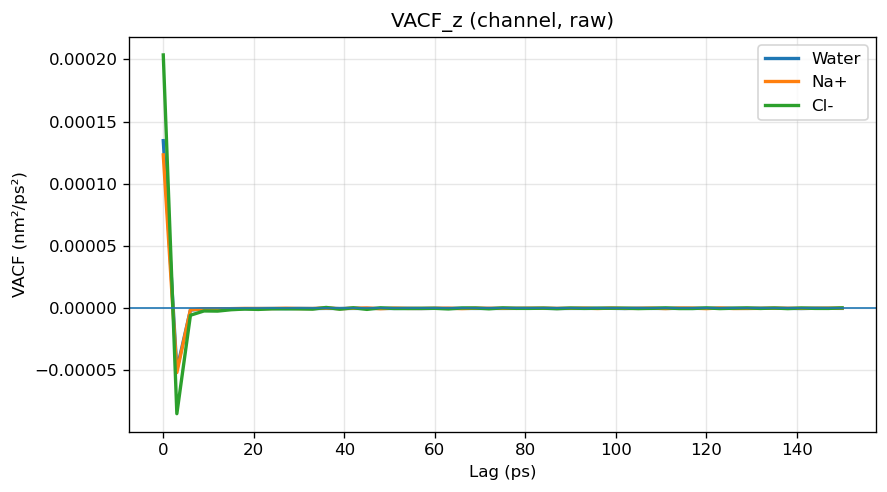

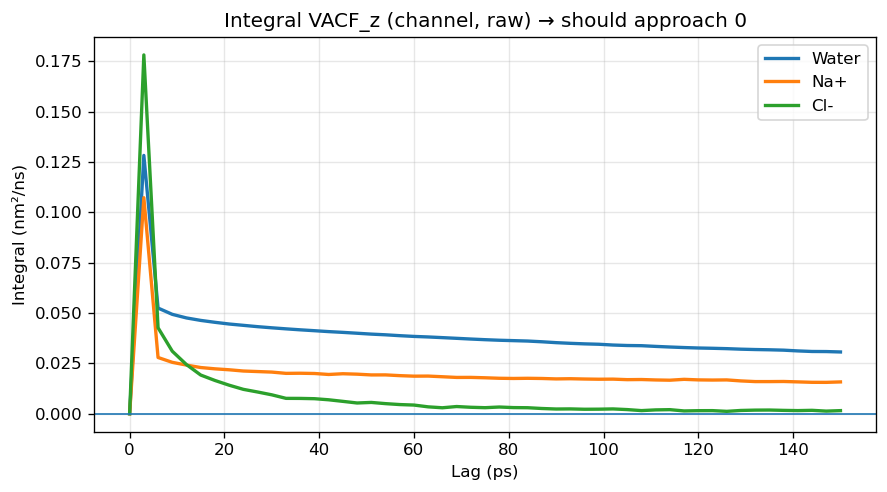

,species,I_z mean(last10) (nm²/ns),std(last10),I_z(last)
0,water,0.031582,0.000637,0.030680
1,na,0.016058,0.000425,0.015803
2,cl,0.001572,0.000203,0.001541


In [22]:
if files["vacf_z_channel_raw"].exists():
    df = read_csv(files["vacf_z_channel_raw"])
    lag = df["lag_ps"] if "lag_ps" in df.columns else df["lag_frames"]

    fig, ax = plt.subplots(figsize=(7.5,4.2))
    ax.plot(lag, df["vacf_z_channel_raw_water_nm2_per_ps2"], label="Water", lw=2)
    ax.plot(lag, df["vacf_z_channel_raw_na_nm2_per_ps2"], label="Na+", lw=2)
    ax.plot(lag, df["vacf_z_channel_raw_cl_nm2_per_ps2"], label="Cl-", lw=2)
    ax.axhline(0, lw=1)
    ax.set_title("VACF_z (channel, raw)")
    ax.set_xlabel("Lag (ps)")
    ax.set_ylabel("VACF (nm²/ps²)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    savefig_and_show("vacf_z_channel_raw", fig)

    fig, ax = plt.subplots(figsize=(7.5,4.2))
    ax.plot(lag, df["I_z_from_vacf_channel_raw_water_nm2_per_ps"]*1000, label="Water", lw=2)
    ax.plot(lag, df["I_z_from_vacf_channel_raw_na_nm2_per_ps"]*1000, label="Na+", lw=2)
    ax.plot(lag, df["I_z_from_vacf_channel_raw_cl_nm2_per_ps"]*1000, label="Cl-", lw=2)
    ax.axhline(0, lw=1)
    ax.set_title("Integral VACF_z (channel, raw) → should approach 0")
    ax.set_xlabel("Lag (ps)")
    ax.set_ylabel("Integral (nm²/ns)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    savefig_and_show("vacf_z_channel_raw_integral", fig)

    rows=[]
    for sp in ["water","na","cl"]:
        mu, sd, last, first = tail_stats(df[f"I_z_from_vacf_channel_raw_{sp}_nm2_per_ps"]*1000, n=10)
        rows.append({"species": sp, "I_z mean(last10) (nm²/ns)": mu, "std(last10)": sd, "I_z(last)": last})
    vacf_z_tbl = show_summary_df(rows, "I_z from VACF (channel, raw)")
    save_table(vacf_z_tbl, "vacf_z_channel_raw_table.csv")


## 8) VACF_x (channel survival) + MSD cross-check summary

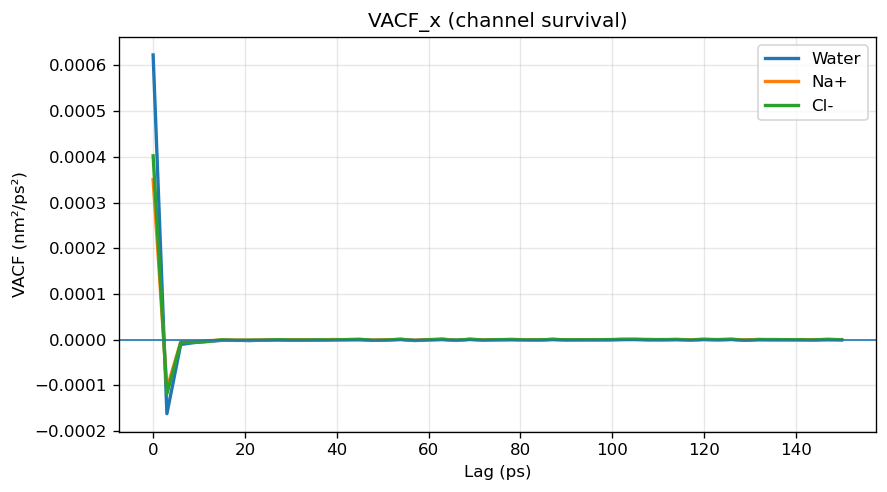

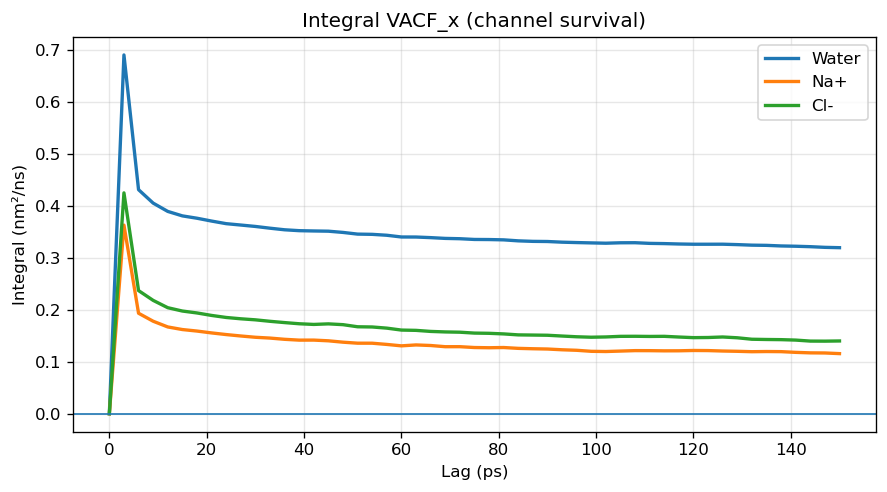

,species,I_x mean(last10) (nm²/ns),std(last10),I_x(last)
0,water,0.323610,0.002396,0.319882
1,na,0.118994,0.001849,0.115800
2,cl,0.143201,0.002944,0.140176


In [23]:
if files["vacf_x_channel"].exists():
    df = read_csv(files["vacf_x_channel"])
    lag = df["lag_ps"] if "lag_ps" in df.columns else df["lag_frames"]

    fig, ax = plt.subplots(figsize=(7.5,4.2))
    ax.plot(lag, df["vacf_x_channel_water_nm2_per_ps2"], label="Water", lw=2)
    ax.plot(lag, df["vacf_x_channel_na_nm2_per_ps2"], label="Na+", lw=2)
    ax.plot(lag, df["vacf_x_channel_cl_nm2_per_ps2"], label="Cl-", lw=2)
    ax.axhline(0, lw=1)
    ax.set_title("VACF_x (channel survival)")
    ax.set_xlabel("Lag (ps)")
    ax.set_ylabel("VACF (nm²/ps²)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    savefig_and_show("vacf_x_channel", fig)

    fig, ax = plt.subplots(figsize=(7.5,4.2))
    ax.plot(lag, df["I_x_from_vacf_channel_water_nm2_per_ps"]*1000, label="Water", lw=2)
    ax.plot(lag, df["I_x_from_vacf_channel_na_nm2_per_ps"]*1000, label="Na+", lw=2)
    ax.plot(lag, df["I_x_from_vacf_channel_cl_nm2_per_ps"]*1000, label="Cl-", lw=2)
    ax.axhline(0, lw=1)
    ax.set_title("Integral VACF_x (channel survival)")
    ax.set_xlabel("Lag (ps)")
    ax.set_ylabel("Integral (nm²/ns)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    savefig_and_show("vacf_x_channel_integral", fig)

    rows=[]
    for sp in ["water","na","cl"]:
        mu, sd, last, first = tail_stats(df[f"I_x_from_vacf_channel_{sp}_nm2_per_ps"]*1000, n=10)
        rows.append({"species": sp, "I_x mean(last10) (nm²/ns)": mu, "std(last10)": sd, "I_x(last)": last})
    vacf_x_tbl = show_summary_df(rows, "I_x from VACF (channel)")
    save_table(vacf_x_tbl, "vacf_x_channel_table.csv")


## 9) Final one-page summary table
Collect the most useful scalar diagnostics for this single system.

In [24]:
rows=[]

# VACF_y plateau
if files["vacf_y"].exists():
    dfy = read_csv(files["vacf_y"])
    for sp in ["water","na","cl"]:
        mu, sd, last, _ = tail_stats(dfy[f"D_y_from_vacf_{sp}_nm2_per_ps"]*1000, n=10)
        rows.append({"observable":"D_y_from_VACF", "species":sp, "value_nm2_per_ns":mu, "std_last10":sd})

# VACF_x integral (channel)
if files["vacf_x_channel"].exists():
    dfx = read_csv(files["vacf_x_channel"])
    for sp in ["water","na","cl"]:
        mu, sd, last, _ = tail_stats(dfx[f"I_x_from_vacf_channel_{sp}_nm2_per_ps"]*1000, n=10)
        rows.append({"observable":"I_x_from_VACF_channel", "species":sp, "value_nm2_per_ns":mu, "std_last10":sd})

# VACF_z integral (channel) ~0
if files["vacf_z_channel_raw"].exists():
    dfz = read_csv(files["vacf_z_channel_raw"])
    for sp in ["water","na","cl"]:
        mu, sd, last, _ = tail_stats(dfz[f"I_z_from_vacf_channel_raw_{sp}_nm2_per_ps"]*1000, n=10)
        rows.append({"observable":"I_z_from_VACF_channel_raw", "species":sp, "value_nm2_per_ns":mu, "std_last10":sd})

summary = pd.DataFrame(rows)
display(summary)
if not summary.empty:
    save_table(summary, "summary_table.csv")
else:
    print("summary table is empty (no compatible VACF files found)")


,observable,species,value_nm2_per_ns,std_last10
0,D_y_from_VACF,water,2.256595,0.001676
1,D_y_from_VACF,na,0.654638,0.001741
2,D_y_from_VACF,cl,0.824326,0.003242
3,I_x_from_VACF_channel,water,0.323610,0.002396
4,I_x_from_VACF_channel,na,0.118994,0.001849
5,I_x_from_VACF_channel,cl,0.143201,0.002944
6,I_z_from_VACF_channel_raw,water,0.031582,0.000637
7,I_z_from_VACF_channel_raw,na,0.016058,0.000425
8,I_z_from_VACF_channel_raw,cl,0.001572,0.000203


['z_center_nm', 'rho_water_mean', 'rho_water_sem', 'rho_na_mean', 'rho_na_sem', 'rho_cl_mean', 'rho_cl_sem', 'count_water_mean', 'count_water_sem', 'count_na_mean', 'count_na_sem', 'count_cl_mean', 'count_cl_sem']


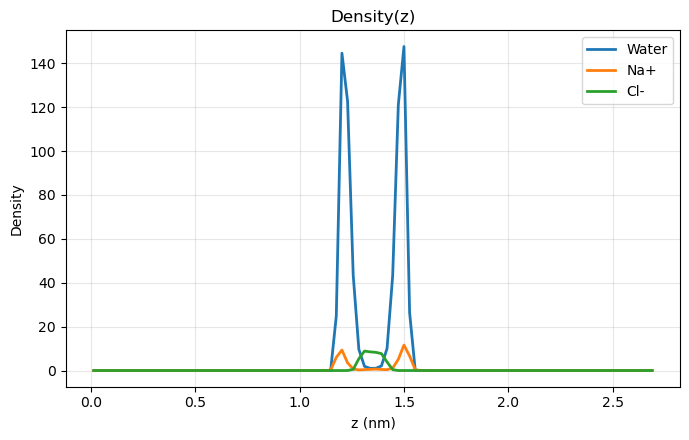

In [2]:
if files["density_z"].exists():
    df = read_csv(files["density_z"])
    print(df.columns.tolist())

    x = "z_center_nm" if "z_center_nm" in df.columns else [c for c in df.columns if c.startswith("z")][0]

    fig, ax = plt.subplots(figsize=(7,4.5))
    if "rho_water_mean" in df.columns:
        ax.plot(df[x], df["rho_water_mean"], label="Water", lw=2)
    if "rho_na_mean" in df.columns:
        ax.plot(df[x], df["rho_na_mean"], label="Na+", lw=2)
    if "rho_cl_mean" in df.columns:
        ax.plot(df[x], df["rho_cl_mean"], label="Cl-", lw=2)

    ax.set_xlabel("z (nm)")
    ax.set_ylabel("Density")
    ax.set_title("Density(z)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    savefig_and_show("density_z", fig)
